# Exercise 1 — Predict Whether a Student Will Pass

## Goal

Build a **binary classification neural network** that predicts whether a student will pass based on:

- `hours_studied`
- `attendance`
- `previous_score`

Target:

- `0` = Fail
- `1` = Pass

### Neural network

```text
hours_studied ───┐
attendance ──────┼──> Dense → ReLU → Dense → Sigmoid → Pass/Fail
previous_score ──┘
```

## Concepts practiced

- neurons
- weights
- biases
- forward propagation
- ReLU
- sigmoid
- binary cross-entropy
- gradient descent
- backpropagation
- epochs
- batches

> **Important:** We will first understand the problem and data, then build the neural network using Keras/TensorFlow.


## 1. The problem

Imagine a school wants to identify students who may be at risk of failing.

For each student, we know:

| Feature | Meaning |
|---|---|
| `hours_studied` | Average study hours per day |
| `attendance` | Attendance percentage |
| `previous_score` | Previous exam/course score |

The model should learn:

```text
Student information
        ↓
Neural network
        ↓
Probability of passing
        ↓
Pass / Fail
```

### Question

Why is this a **classification** problem rather than a regression problem?


## 2. Load the dataset

The dataset is in:

`student_pass_dataset.csv`

### Your task

Load the CSV into a pandas DataFrame and display the first 10 rows.


In [3]:
# TODO: import pandas and load the dataset

import pandas as pd
df = pd.read_csv("dataset/student_pass_dataset.csv")
df.head(10)


,student_id,hours_studied,attendance,previous_score,passed
0,1,0.9,81.0,64.6,0
1,2,5.7,83.9,83.4,1
2,3,4.5,100.0,51.5,1
3,4,4.8,100.0,71.3,0
4,5,3.4,59.3,57.2,0
5,6,10.6,87.5,68.6,1
6,7,4.4,87.2,45.1,0
7,8,4.1,82.9,73.7,0
8,9,5.7,91.1,68.1,0
9,10,5.0,81.4,84.6,0


## 3. Explore the data

Answer these questions:

1. How many students are in the dataset?
2. What are the input features?
3. What is the target?
4. Are there missing values?
5. How many students passed?
6. How many students failed?

Try using:

```python
df.shape
df.info()
df.isnull().sum()
df["passed"].value_counts()
```


In [4]:
# TODO: explore the dataset

# 600 entries
# [hours_studied, attendance, previous_score ]
# 'passsed' is target variable
# no missing values
# 400 students failed
# 200 students passed

print('shape of dataset: ',df.shape)

print ('\n',df.info())
print ('total null: \n',df.isnull().sum())
df["passed"].value_counts()


shape of dataset:  (600, 5)
<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   student_id      600 non-null    int64  
 1   hours_studied   600 non-null    float64
 2   attendance      600 non-null    float64
 3   previous_score  600 non-null    float64
 4   passed          600 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 23.6 KB

 None
total null: 
 student_id        0
hours_studied     0
attendance        0
previous_score    0
passed            0
dtype: int64


passed
0    400
1    200
Name: count, dtype: int64

## 4. Separate inputs and target

The neural network needs:

```text
X = input features
y = target
```

Use the three columns:

```text
hours_studied
attendance
previous_score
```

as `X`.

Use:

```text
passed
```

as `y`.

### Question

Why should `student_id` NOT be used as an input feature?


In [5]:
# TODO: create X and y
# student_id is irrelevant feature (it doesn't decide pass or fail)

# X = ...
# y = ...
X= df[['hours_studied','attendance','previous_score']]
y= df['passed']
y


0      0
1      1
2      1
3      0
4      0
      ..
595    1
596    0
597    1
598    1
599    0
Name: passed, Length: 600, dtype: int64

## 5. Train/test split

We need to evaluate the model on students it has not seen during training.

Use:

- 80% training data
- 20% testing data
- `random_state=42`
- `stratify=y`

Why is `stratify=y` useful for a classification problem?


In [6]:
# TODO: split X and y into training and testing sets

from sklearn.model_selection import train_test_split


# stratify = y: parameter ensures that the proportion of classes in your dataset is preserved across both your training and testing sets.
X_train, X_test,y_train, y_test= train_test_split(
    X, y,
    test_size= 0.2,
    random_state= 42,
    stratify=y 
)


## 6. Scale the features

Notice that our features have different ranges:

```text
hours_studied   → roughly 0–12
attendance      → roughly 35–100
previous_score  → roughly 20–100
```

Neural networks usually train more effectively when numerical inputs are on similar scales.

Use `StandardScaler`.

**Important:** fit the scaler only on the training data, then transform both training and test data.


In [7]:
# TODO: standardize X_train and X_test

from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)


## 7. Build the neural network

Create this architecture:

```text
Input: 3 features
       ↓
Dense(8)
       ↓
ReLU
       ↓
Dense(4)
       ↓
ReLU
       ↓
Dense(1)
       ↓
Sigmoid
       ↓
Probability of passing
```

### Think about the layers

- Why are there 3 input values?
- Why do we use ReLU in the hidden layers?
- Why does the final layer have only 1 neuron?
- Why do we use sigmoid at the output?


In [8]:
# TODO: import TensorFlow/Keras and build the model

# b/c there is 3 features for prediction
# to avoid linearity of the layer and helps to avoid unnecessary features
# at the end there should one prediction
# because it is classification (0/1)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

model = keras.Sequential([
        layers.Dense(8, activation= 'relu', input_shape= (3,)),
        layers.Dense(4, activation="relu"),
        layers.Dense(1, activation="sigmoid"),

])

model.summary()



c:\Users\Abi\Desktop\deep learning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73 (292.00 B)

 Trainable params: 73 (292.00 B)

 Non-trainable params: 0 (0.00 B)

## 8. Compile the model

Use:

- optimizer: `adam`
- loss: `binary_crossentropy`
- metric: `accuracy`

### Important concept

During training:

```text
prediction
    ↓
binary cross-entropy
    ↓
loss
    ↓
backpropagation
    ↓
gradients
    ↓
update weights
```

The optimizer uses the gradients to update the network's weights.


In [9]:
# TODO: compile the model
model.compile(
    optimizer="adam", 
    loss="binary_crossentropy", 
    metrics=["accuracy"]
)


## 9. Train the model

Train for around **50 epochs** with:

- batch size = 16
- validation split = 20%

Watch the training and validation loss.

### Questions

1. Does the loss generally decrease?
2. What does one epoch mean?
3. What does the batch size control?
4. Why might training accuracy continue increasing while validation accuracy stops improving?


In [10]:
# TODO: train the model

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)



Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.3776 - loss: 0.7524 - val_accuracy: 0.5000 - val_loss: 0.6988
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4349 - loss: 0.7127 - val_accuracy: 0.6146 - val_loss: 0.6774
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5286 - loss: 0.6830 - val_accuracy: 0.6771 - val_loss: 0.6604
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6354 - loss: 0.6585 - val_accuracy: 0.7083 - val_loss: 0.6452
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7240 - loss: 0.6367 - val_accuracy: 0.6979 - val_loss: 0.6309
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7630 - loss: 0.6166 - val_accuracy: 0.7083 - val_loss: 0.6170
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7734 - loss: 0.5971 - val_accuracy: 0.7083 - val_loss: 0.6031
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7786 - loss: 0.5780 - val_accuracy: 0.7188 - val_lo

## 10. Plot the learning curves

Plot:

1. training loss vs validation loss
2. training accuracy vs validation accuracy

Look for evidence of:

- learning
- underfitting
- overfitting


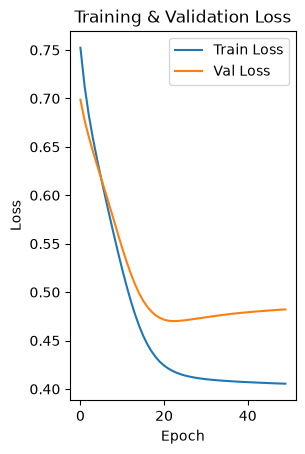

In [11]:
# TODO: plot training and validation loss

# Even though accuracy on validation is best, mildy overfitting (it tries to memorize the training data) exists

import matplotlib.pyplot as plt
import seaborn as sns

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()


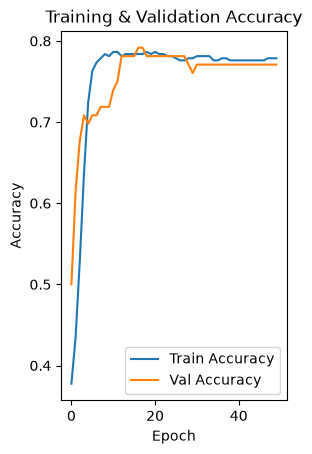

In [12]:
# TODO: plot training and validation accuracy

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


## 11. Evaluate on the test set

Calculate:

- test loss
- test accuracy

Remember:

> The test set should represent data the model did not use to learn its weights.


In [13]:
# TODO: evaluate the model on the test set

test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.4229
Test Accuracy: 0.7750


## 12. Make predictions

The sigmoid output is a probability between 0 and 1.

For example:

```text
0.92 → likely pass
0.18 → likely fail
```

Use a threshold of `0.5`:

```python
prediction >= 0.5 → 1
prediction < 0.5  → 0
```

Make predictions for the test set.


In [14]:
# TODO: generate probabilities and convert them to 0/1 predictions
y_probs = model.predict(X_test_scaled)
y_preds = (y_probs >= 0.5).astype(int)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


## 13. Confusion matrix

Create a confusion matrix.

Interpret:

- True Positive
- True Negative
- False Positive
- False Negative

### Question

Which mistake would you consider more serious in a school intervention system?

**False positive:** the model says a student will pass, but they fail.

**False negative:** the model says a student will fail, but they pass.

Explain your reasoning.


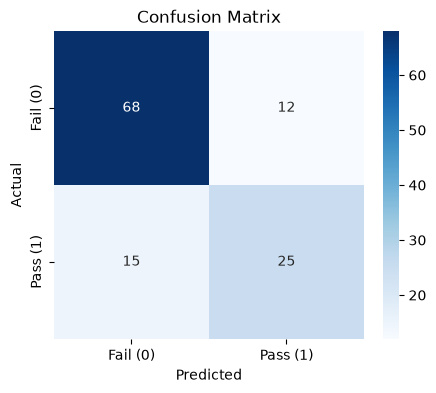


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83        80
           1       0.68      0.62      0.65        40

    accuracy                           0.78       120
   macro avg       0.75      0.74      0.74       120
weighted avg       0.77      0.78      0.77       120



In [15]:
# TODO: create and display a confusion matrix

# false positive is more important because student may continues enrolling while still failing

from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(y_test, y_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail (0)", "Pass (1)"],
    yticklabels=["Fail (0)", "Pass (1)"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_preds))


## 14. Try your own students

Create 5 hypothetical students.

Example:

```text
hours_studied = 8
attendance = 92
previous_score = 78
```

Ask the neural network to predict their probability of passing.

Try some borderline cases too.

### Challenge

Can you find a student for whom the model is uncertain, such as a prediction around:

```text
0.45–0.55
```

Why might the model be uncertain?


In [16]:
# TODO: create your own student examples and predict their probabilities

custom_students = pd.DataFrame(
    [
        {"hours_studied": 8.0, "attendance": 92.0, "previous_score": 78.0},
        {"hours_studied": 1.0, "attendance": 40.0, "previous_score": 30.0},
        {"hours_studied": 4.5, "attendance": 80.0, "previous_score": 60.0},  # Borderline
        {"hours_studied": 3.0, "attendance": 85.0, "previous_score": 55.0},  # Borderline
        {"hours_studied": 6.0, "attendance": 50.0, "previous_score": 90.0},
    ]
)
custom_students_scaled= scaler.transform(custom_students)

custom_predicted=model.predict(custom_students_scaled)

for i, row in custom_students.iterrows():
    prob = custom_predicted[i][0]
    status = "Pass" if prob >= 0.5 else "Fail"
    print(
        f"Student {i+1}: Study={row['hours_studied']}h, Att={row['attendance']}%, PrevScore={row['previous_score']} -> Prob Pass: {prob:.4f} ({status})"
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Student 1: Study=8.0h, Att=92.0%, PrevScore=78.0 -> Prob Pass: 0.8460 (Pass)
Student 2: Study=1.0h, Att=40.0%, PrevScore=30.0 -> Prob Pass: 0.0001 (Fail)
Student 3: Study=4.5h, Att=80.0%, PrevScore=60.0 -> Prob Pass: 0.0915 (Fail)
Student 4: Study=3.0h, Att=85.0%, PrevScore=55.0 -> Prob Pass: 0.0291 (Fail)
Student 5: Study=6.0h, Att=50.0%, PrevScore=90.0 -> Prob Pass: 0.2751 (Fail)


# Reflection

Answer these questions in your own words:

1. What is a neuron doing?
2. What is the purpose of a weight?
3. What is a bias?
4. What happens during forward propagation?
5. Why do we need an activation function?
6. Why is sigmoid useful for binary classification?
7. What does binary cross-entropy measure?
8. What happens during backpropagation?
9. What does gradient descent change?
10. What is an epoch?
11. What is a batch?
12. Why do we keep a separate test set?

## Final challenge

Change the architecture and compare:

```text
Model A:
3 → 4 → 1

Model B:
3 → 8 → 4 → 1

Model C:
3 → 32 → 16 → 8 → 1
```

Compare their validation and test performance.

**Question:** Does a bigger network always perform better?


                                        Answers to Reflection
1. ​Neuron: Computes z = \sum (w_i x_i) + b, then applies an activation function f(z).
2. ​Weight (w): Controls the sensitivity/importance of an input signal to the neuron output.
3. ​Bias (b): Allows shifting the activation curve independently of inputs.

4. ​Forward Propagation: Passing inputs layer-by-layer to compute final model output probabilities.
5. ​Activation Function: Introduces non-linear mathematical operations so the network can fit non-linear patterns.

6. ​Why Sigmoid Is Useful for Binary Classification
​Probability Output: Sigmoid squashes any real-numbered input value into a strict [0, 1] interval, transforming arbitrary neuron outputs into valid probabilities.
​Clear Decision Threshold: By mapping outputs to probabilities, it allows simple thresholding (typically 0.5) to make clear binary decisions (e.g., values \ge 0.5 predict Class 1, while < 0.5 predict Class 0).

7. ​Binary Cross-Entropy: Penalizes predictions proportional to how far calculated probabilities lie from actual binary labels (0 or 1).
​8 & 9. Backpropagation & Gradient Descent: Backpropagation calculates loss gradients across weights via the chain rule; gradient descent updates weights in the direction that minimizes loss.

10 & 11.​Epoch vs Batch: Epoch is 1 full pass over all training samples; batch size is the subset of samples processed before updating weights.


12. Unbiased Evaluation: The test set acts as unseen real-world data. It measures how well the model generalizes to brand-new data rather than just memorizing training examples.Comparing performance on training/validation data against the test set reveals if the model overfit to hyperparameter tuning decisions made during development



# Final challenge

In [ ]:
# 